<a href="https://colab.research.google.com/github/Holanpasaribu12/UAS/blob/main/UTS_MachineLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Processed Dataset.csv to Processed Dataset.csv
Saving Raw Dataset.csv to Raw Dataset.csv


Saving Processed Dataset.csv to Processed Dataset (4).csv
Saving Raw Dataset.csv to Raw Dataset (4).csv
File: Processed Dataset (4).csv

=== Data Awal ===
      itemId             name                                reviewTitle  \
0  100002528         Kamal U.                                        NaN   
1  100002528       yofanca m.                                        NaN   
2  100002528  Lazada Customer  ok mantaaapppp barang sesuai pesanan good   
3  100002528  Lazada Customer                                        NaN   
4  100002528        nurfarida                     ada pengirimn ntb bima   

                     reviewContent sentiment_label  confidence  rating  \
0  bagus  mantap dah sesui pesanan        positive    0.996603     5.0   
1                bagus sesuai foto        positive    0.784520     4.0   
2    okkkkk mantaaaaaaapppp  goood        positive    0.503112     5.0   
3                     bagus sesuai        positive    0.800715     4.0   
4                 

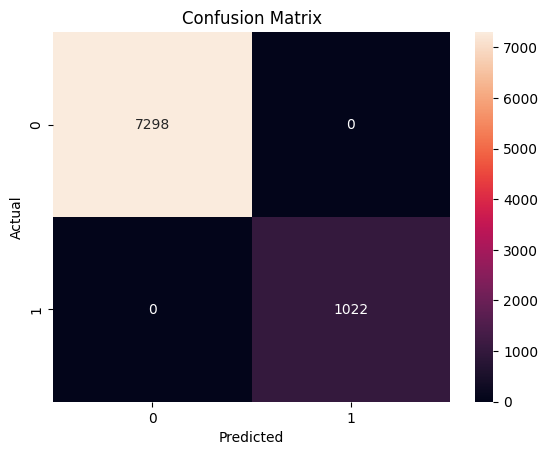

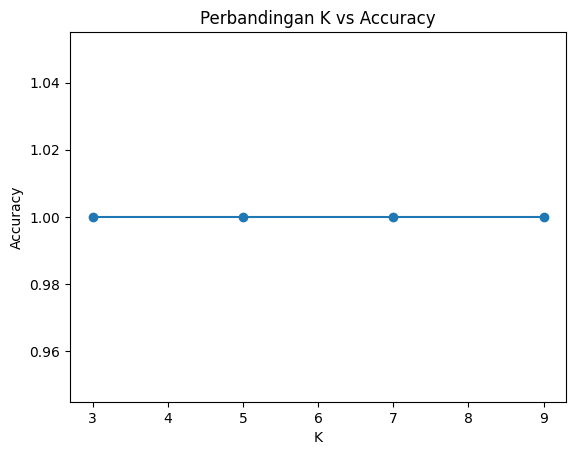

In [5]:
# =========================================
# UPLOAD FILE CSV
# =========================================
from google.colab import files
uploaded = files.upload()

# =========================================
# IMPORT LIBRARY
# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

# =========================================
# LOAD DATASET
# =========================================
file_name = list(uploaded.keys())[0]
print(f"File: {file_name}")

data = pd.read_csv(file_name)

print("\n=== Data Awal ===")
print(data.head())

# =========================================
# HANDLE MISSING VALUE
# =========================================
print("\nCek Missing Value:")
print(data.isnull().sum())

# Ambil hanya kolom penting
data = data[['rating', 'confidence', 'relevanceScore']]

# Hapus data kosong
data = data.dropna()

print("\nSetelah cleaning:")
print(data.isnull().sum())

# =========================================
# BUAT LABEL KEPUASAN
# =========================================
data['Satisfaction'] = data['rating'].apply(lambda x: 'Puas' if x >= 4 else 'Tidak_Puas')

# =========================================
# FITUR & LABEL (REVISI DI SINI 🔥)
# =========================================
X = data[['confidence', 'relevanceScore', 'rating']]
y = data['Satisfaction']

# Encoding label
le = LabelEncoder()
y = le.fit_transform(y)

# Normalisasi
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# =========================================
# SPLIT DATA
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================================
# UJI NILAI K
# =========================================
print("\n=== Uji Nilai K ===")
k_values = [3, 5, 7, 9]
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    print(f"K = {k}, Accuracy = {acc:.4f}")

# =========================================
# PILIH K TERBAIK
# =========================================
best_k = k_values[np.argmax(accuracies)]
print(f"\nBest K: {best_k}")

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

# =========================================
# EVALUASI
# =========================================
print("\n=== Evaluasi Model ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# =========================================
# VISUALISASI
# =========================================
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

plt.figure()
plt.plot(k_values, accuracies, marker='o')
plt.title("Perbandingan K vs Accuracy")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.show()